## Importing Necessary Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import defaultdict
import cv2
import math
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

## Question 2: (d) - Sampling and Decision Boundary Visualization

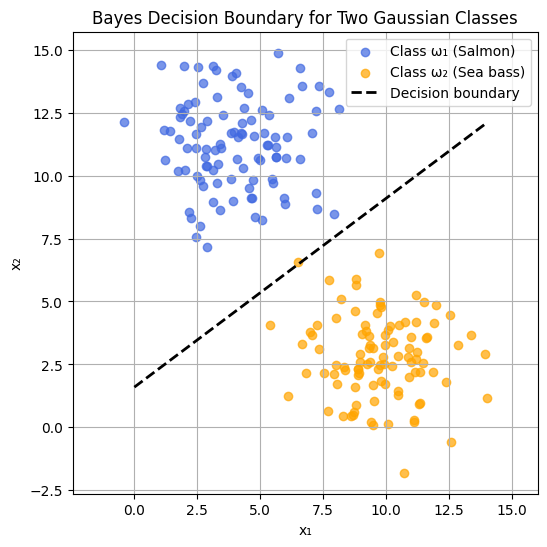

In [2]:
mu1 = np.array([4, 11])
mu2 = np.array([10, 3])
Sigma = 3 * np.eye(2)
P1, P2 = 0.6, 0.4

np.random.seed(0)
x1 = np.random.multivariate_normal(mu1, Sigma, 100)
x2 = np.random.multivariate_normal(mu2, Sigma, 100)

x1_range = np.linspace(0, 14, 200)
boundary = (6 * x1_range + 14 + 3 * np.log(2/3)) / 8

plt.figure(figsize=(6, 6))
plt.scatter(x1[:, 0], x1[:, 1], color='royalblue', label='Class ω₁ (Salmon)', alpha=0.7)
plt.scatter(x2[:, 0], x2[:, 1], color='orange', label='Class ω₂ (Sea bass)', alpha=0.7)
plt.plot(x1_range, boundary, 'k--', linewidth=2, label='Decision boundary')

plt.title("Bayes Decision Boundary for Two Gaussian Classes")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

## Question 7: Naive Bayes Warm-Up (Part 2)

In [3]:
X = np.array([
    [0,1],
    [1,1],
    [0,0],
    [1,1],
    [1,1],
    [0,0],
    [1,0],
    [1,0],
    [1,1],
    [1,0]
])
y = np.array([1,1,0,1,1,0,0,0,1,0])

P_y1 = np.mean(y == 1)
P_y0 = np.mean(y == 0)

P_x1_y1 = np.mean(X[y == 1, 0] == 1)
P_x2_y1 = np.mean(X[y == 1, 1] == 1)
P_x1_y0 = np.mean(X[y == 0, 0] == 1)
P_x2_y0 = np.mean(X[y == 0, 1] == 1)

x_test = np.array([1, 1])
P_y1_given_x = P_y1 * (P_x1_y1 ** x_test[0]) * (P_x2_y1 ** x_test[1])
P_y0_given_x = P_y0 * (P_x1_y0 ** x_test[0]) * (P_x2_y0 ** x_test[1])
total = P_y1_given_x + P_y0_given_x
P_y1_given_x /= total
P_y0_given_x /= total

predicted_label = 1 if P_y1_given_x > P_y0_given_x else 0

print("P(y=1) =", P_y1)
print("P(y=0) =", P_y0)
print("Conditional probabilities:")
print("  P(x1=1|y=1) =", P_x1_y1)
print("  P(x2=1|y=1) =", P_x2_y1)
print("  P(x1=1|y=0) =", P_x1_y0)
print("  P(x2=1|y=0) =", P_x2_y0)
print("\nPosterior probabilities for x=[1,1]:")
print("  P(y=1|x) =", round(P_y1_given_x, 3))
print("  P(y=0|x) =", round(P_y0_given_x, 3))
print("Predicted label =", predicted_label)

P(y=1) = 0.5
P(y=0) = 0.5
Conditional probabilities:
  P(x1=1|y=1) = 0.8
  P(x2=1|y=1) = 1.0
  P(x1=1|y=0) = 0.6
  P(x2=1|y=0) = 0.0

Posterior probabilities for x=[1,1]:
  P(y=1|x) = 1.0
  P(y=0|x) = 0.0
Predicted label = 1


## Question 8: Classifying Spam with Naive Bayes

### Part 2 – Compute Prior Probabilities P(spam) and P(ham)

In [4]:
train_path = "dataset/train"

num_spam = 0
num_ham = 0
num_total = 0

with open(train_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        num_total += 1
        label = line.split()[1]
        if label == "spam":
            num_spam += 1
        else:
            num_ham += 1

P_spam = num_spam / num_total
P_ham = num_ham / num_total

print(f"Total emails: {num_total}")
print(f"Spam emails: {num_spam}")
print(f"Ham emails: {num_ham}")
print(f"P(spam) = {P_spam:.4f}")
print(f"P(ham)  = {P_ham:.4f}")

Total emails: 9000
Spam emails: 5163
Ham emails: 3837
P(spam) = 0.5737
P(ham)  = 0.4263


### Part 3 - Conditional Word Probabilities

In [5]:
word_counts_spam = defaultdict(int)
word_counts_ham  = defaultdict(int)
total_words_spam = 0
total_words_ham  = 0

with open(train_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 3:
            continue
        label = parts[1]
        for i in range(2, len(parts), 2):
            word = parts[i]
            count = int(parts[i+1])
            if label == "spam":
                word_counts_spam[word] += count
                total_words_spam += count
            else:
                word_counts_ham[word] += count
                total_words_ham += count

vocab = set(list(word_counts_spam.keys()) + list(word_counts_ham.keys()))
V = len(vocab)

m = V
p = 1 / V

P_word_given_spam = {}
P_word_given_ham  = {}

for word in vocab:
    n_spam = word_counts_spam[word]
    n_ham  = word_counts_ham[word]
    P_word_given_spam[word] = (n_spam + m * p) / (total_words_spam + m)
    P_word_given_ham[word]  = (n_ham  + m * p) / (total_words_ham  + m)

# Finding the top 5 most likely words for each class 
top_spam_words = sorted(P_word_given_spam.items(), key=lambda x: x[1], reverse=True)[:5]
top_ham_words  = sorted(P_word_given_ham.items(), key=lambda x: x[1], reverse=True)[:5]

print("Vocabulary size:", V)
print("\nTop 5 words given SPAM:")
for w, p_val in top_spam_words:
    print(f"  {w}: {p_val:.6f}")

print("\nTop 5 words given HAM:")
for w, p_val in top_ham_words:
    print(f"  {w}: {p_val:.6f}")

Vocabulary size: 1000

Top 5 words given SPAM:
  enron: 0.038194
  a: 0.023619
  corp: 0.021738
  the: 0.021425
  to: 0.019687

Top 5 words given HAM:
  aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa: 0.044322
  enron: 0.042444
  the: 0.033169
  to: 0.025330
  a: 0.017737


### Part 4 - Classifying Test Data and Compute Accuracy

In [6]:
test_path = "dataset/test"

correct = 0
total = 0

with open(test_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 3:
            continue
        true_label = parts[1]

        log_prob_spam = math.log(P_spam)
        log_prob_ham  = math.log(P_ham)

        for i in range(2, len(parts), 2):
            word = parts[i]
            count = int(parts[i+1])

            if word in vocab:
                log_prob_spam += count * math.log(P_word_given_spam[word])
                log_prob_ham  += count * math.log(P_word_given_ham[word])

        predicted_label = "spam" if log_prob_spam > log_prob_ham else "ham"
        if predicted_label == true_label:
            correct += 1
        total += 1

accuracy = correct / total
print(f"Total test emails: {total}")
print(f"Correct predictions: {correct}")
print(f"Accuracy: {accuracy:.4f}")

Total test emails: 1000
Correct predictions: 902
Accuracy: 0.9020


### Part 5 - Effect of the m Parameter

m=      1000, Accuracy=0.9020
m=     10000, Accuracy=0.9040
m=    100000, Accuracy=0.9040
m=   1000000, Accuracy=0.8710
m=  10000000, Accuracy=0.7650


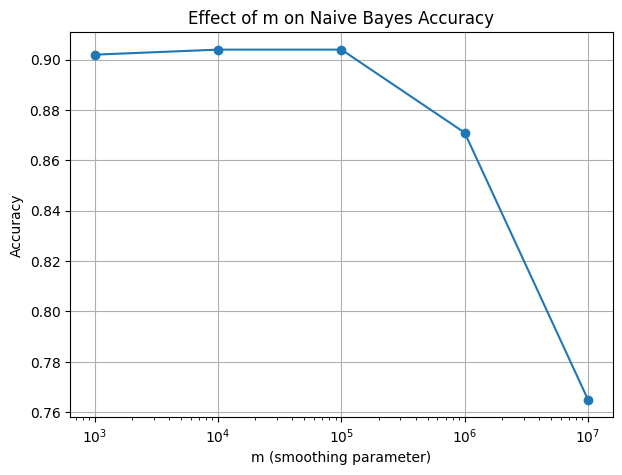

In [7]:
m_values = [V * k for k in [1, 10, 100, 1000, 10000]]
accuracies = []

for m in m_values:
    p = 1 / V

    P_word_given_spam_m = {}
    P_word_given_ham_m = {}
    for word in vocab:
        n_spam = word_counts_spam[word]
        n_ham  = word_counts_ham[word]
        P_word_given_spam_m[word] = (n_spam + m * p) / (total_words_spam + m)
        P_word_given_ham_m[word]  = (n_ham  + m * p) / (total_words_ham  + m)

    correct = 0
    total = 0
    with open("dataset/test", "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            true_label = parts[1]

            log_prob_spam = math.log(P_spam)
            log_prob_ham  = math.log(P_ham)

            for i in range(2, len(parts), 2):
                word = parts[i]
                count = int(parts[i+1])
                if word in vocab:
                    log_prob_spam += count * math.log(P_word_given_spam_m[word])
                    log_prob_ham  += count * math.log(P_word_given_ham_m[word])

            predicted_label = "spam" if log_prob_spam > log_prob_ham else "ham"
            if predicted_label == true_label:
                correct += 1
            total += 1

    acc = correct / total
    accuracies.append(acc)
    print(f"m={m:>10}, Accuracy={acc:.4f}")

plt.figure(figsize=(7,5))
plt.plot(m_values, accuracies, marker="o")
plt.xscale("log")
plt.xlabel("m (smoothing parameter)")
plt.ylabel("Accuracy")
plt.title("Effect of m on Naive Bayes Accuracy")
plt.grid(True)
plt.show()

## Question 9: Cloud vs. Clear Sky

### Part 1 - Simple HSV-based Cloud vs Clear Classifier

In [8]:
img_dir = "Images"

# Compute the mean saturation value of an image (normalized 0–1)
def compute_saturation(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_s = np.mean(hsv[:, :, 1]) / 255.0
    return mean_s

features = []
labels = []

for filename in os.listdir(img_dir):
    if filename.endswith(".jpg"):
        path = os.path.join(img_dir, filename)
        mean_s = compute_saturation(path)
        label = 1 if filename.startswith("s") else 0  # 1: clear, 0: cloudy
        features.append([mean_s])
        labels.append(label)

features = np.array(features)
labels = np.array(labels)

### Part 2 – Test the Classifier and Compute Evaluation Metrics

In [9]:
T_S = 0.42

predictions = []
for s in features:
    if (s < T_S):
        predictions.append(0)   
    else:
        predictions.append(1)   

predictions = np.array(predictions)

cm = confusion_matrix(labels, predictions)
precision = precision_score(labels, predictions, pos_label=0)
recall = recall_score(labels, predictions, pos_label=0)
accuracy = accuracy_score(labels, predictions)

print("Confusion Matrix:\n", cm)
print(f"Precision (Cloudy class): {precision:.3f}")
print(f"Recall (Cloudy class): {recall:.3f}")
print(f"Overall Accuracy: {accuracy:.3f}")

Confusion Matrix:
 [[31  9]
 [ 5 35]]
Precision (Cloudy class): 0.861
Recall (Cloudy class): 0.775
Overall Accuracy: 0.825


### Part 3 - Exploring New Classification Criteria

In [10]:
# Function to compute mean saturation and brightness for an image
def compute_hsv_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_s = np.mean(hsv[:, :, 1]) / 255.0  
    mean_v = np.mean(hsv[:, :, 2]) / 255.0
    return mean_s, mean_v



features = []
labels = []

for filename in os.listdir(img_dir):
    if filename.endswith(".jpg"):
        path = os.path.join(img_dir, filename)
        mean_s, mean_v = compute_hsv_features(path)
        label = 1 if filename.startswith("s") else 0
        features.append([mean_s, mean_v])
        labels.append(label)

Ploting feature distribution:

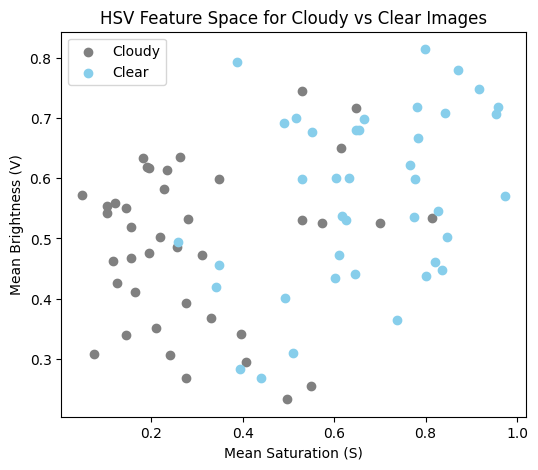

Chosen thresholds T_S = 0.42, T_V = 0.7


In [11]:
features = np.array(features)
labels = np.array(labels)
cloudy_idx = labels == 0
clear_idx = labels == 1

plt.figure(figsize=(6, 5))
plt.scatter(features[cloudy_idx, 0], features[cloudy_idx, 1],
            c="gray", label="Cloudy")
plt.scatter(features[clear_idx, 0], features[clear_idx, 1],
            c="skyblue", label="Clear")
plt.xlabel("Mean Saturation (S)")
plt.ylabel("Mean Brightness (V)")
plt.title("HSV Feature Space for Cloudy vs Clear Images")
plt.legend()
plt.show()

T_S, T_V = 0.42, 0.7
print(f"Chosen thresholds T_S = {T_S}, T_V = {T_V}")

Evaluating the improved classifier:

In [12]:
predictions = []
for s, v in features:
    if (s < T_S) and (v < T_V):
        predictions.append(0)   
    else:
        predictions.append(1)   

predictions = np.array(predictions)

# Compute metrics
cm = confusion_matrix(labels, predictions)
precision = precision_score(labels, predictions, pos_label=0)
recall = recall_score(labels, predictions, pos_label=0)
accuracy = accuracy_score(labels, predictions)

print("Confusion Matrix:\n", cm)
print(f"Precision (Cloudy class): {precision:.3f}")
print(f"Recall (Cloudy class): {recall:.3f}")
print(f"Overall Accuracy: {accuracy:.3f}")

Confusion Matrix:
 [[31  9]
 [ 4 36]]
Precision (Cloudy class): 0.886
Recall (Cloudy class): 0.775
Overall Accuracy: 0.838


### Part 4 - Show and Discuss Misclassified Images

Total misclassified images: 13


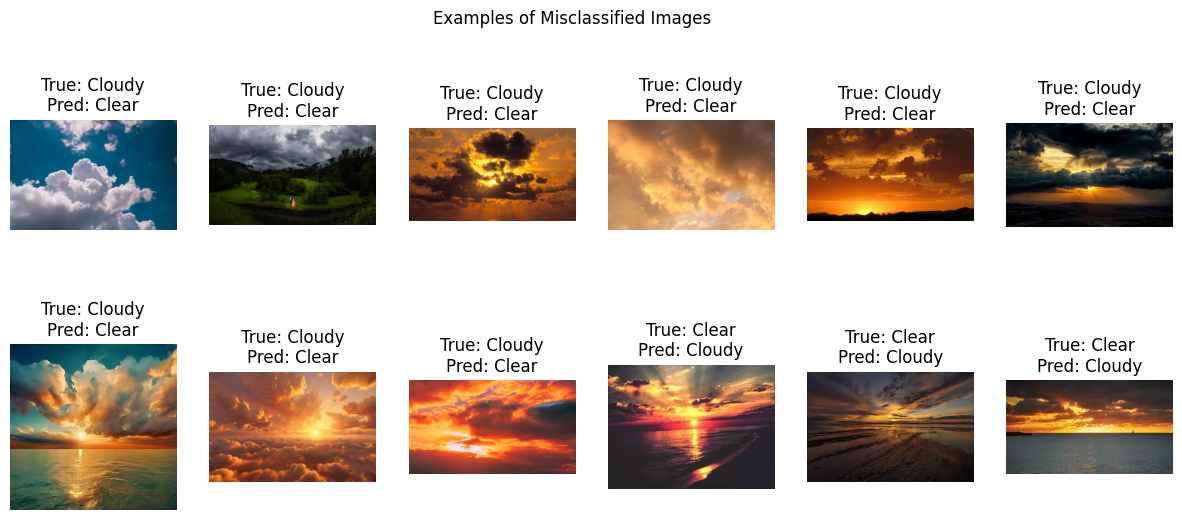

In [13]:
misclassified_indices = np.where(predictions != labels)[0]
print(f"Total misclassified images: {len(misclassified_indices)}")

n_show = min(12, len(misclassified_indices))
plt.figure(figsize=(15, 6))

for i, idx in enumerate(misclassified_indices[:n_show]):
    filename = sorted(os.listdir(img_dir))[idx]
    img_path = os.path.join(img_dir, filename)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    true_label = "Cloudy" if labels[idx] == 0 else "Clear"
    pred_label = "Cloudy" if predictions[idx] == 0 else "Clear"
    
    plt.subplot(2, 6, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True: {true_label}\nPred: {pred_label}")
plt.suptitle("Examples of Misclassified Images")
plt.show()